### 1. Data Loading and Initial Setup
We begin by extracting the dataset and loading it into a Pandas DataFrame. all 6.3m+

In [9]:
!pip install xgboost shap imbalanced-learn optuna joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00


In [10]:
import pandas as pd
import zipfile
import os

zip_path = "/content/paysim_financial.zip"
extract_path = "/content/paysim_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

csv_file = [f for f in os.listdir(extract_path) if f.endswith('.csv')][0]

df = pd.read_csv(
    os.path.join(extract_path, csv_file)
)

print(df.shape)

(6362620, 11)


Step 3: Feature Engineering

In [11]:
df.drop(
    columns=["nameOrig","nameDest"],
    inplace=True
)

df["sender_balance_change"] = (
    df["oldbalanceOrg"]
    - df["newbalanceOrig"]
)

df["receiver_balance_change"] = (
    df["newbalanceDest"]
    - df["oldbalanceDest"]
)

df["balance_error_origin"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["balance_error_destination"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

df["high_amount_flag"] = (
    df["amount"] > 200000
).astype(int)

df["zero_balance_anomaly"] = (
    (df["oldbalanceOrg"] > 0)
    &
    (df["newbalanceOrig"] == 0)
).astype(int)

df["drain_ratio"] = (
    (df["oldbalanceOrg"]
     - df["newbalanceOrig"])
    /
    (df["oldbalanceOrg"] + 1)
)

### 2. Exploratory Data Analysis (EDA)
We will now examine the data structure, missing values, and the distribution of fraud vs. legitimate transactions.

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 16 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   step                       int64  
 1   type                       object 
 2   amount                     float64
 3   oldbalanceOrg              float64
 4   newbalanceOrig             float64
 5   oldbalanceDest             float64
 6   newbalanceDest             float64
 7   isFraud                    int64  
 8   isFlaggedFraud             int64  
 9   sender_balance_change      float64
 10  receiver_balance_change    float64
 11  balance_error_origin       float64
 12  balance_error_destination  float64
 13  high_amount_flag           int64  
 14  zero_balance_anomaly       int64  
 15  drain_ratio                float64
dtypes: float64(10), int64(5), object(1)
memory usage: 776.7+ MB


None


--- Missing Values ---
step                         0
type                         0
amount                       0
oldbalanceOrg                0
newbalanceOrig               0
oldbalanceDest               0
newbalanceDest               0
isFraud                      0
isFlaggedFraud               0
sender_balance_change        0
receiver_balance_change      0
balance_error_origin         0
balance_error_destination    0
high_amount_flag             0
zero_balance_anomaly         0
drain_ratio                  0
dtype: int64

--- Fraud Distribution ---
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Percentage: 0.1291%


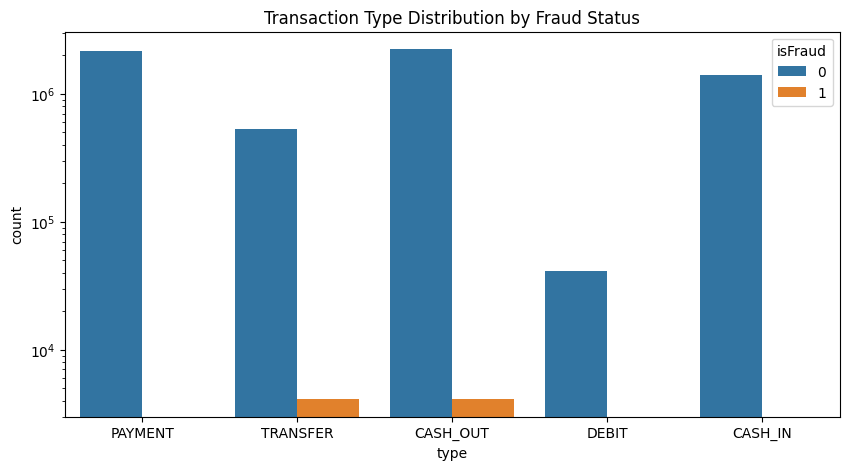

In [12]:
# Dataset Info
print("--- Dataset Information ---")
display(df.info())

# Missing Values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Fraud Distribution
print("\n--- Fraud Distribution ---")
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)
print(f"Fraud Percentage: {(fraud_counts[1]/len(df))*100:.4f}%")

# Transaction Type Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title('Transaction Type Distribution by Fraud Status')
plt.yscale('log') # Log scale to see fraud clearly among millions of transactions
plt.show()

### 3. Column Explanations
Based on the PaySim documentation:
- **step**: Maps a unit of time in the real world. In this case 1 step is 1 hour of time.
- **type**: CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
- **amount**: amount of the transaction in local currency.
- **nameOrig**: customer who started the transaction.
- **oldbalanceOrg**: initial balance before the transaction.
- **newbalanceOrig**: new balance after the transaction.
- **nameDest**: customer who is the recipient of the transaction.
- **oldbalanceDest**: initial balance recipient before the transaction.
- **newbalanceDest**: new balance recipient after the transaction.
- **isFraud**: This is the transactions made by the fraudulent agents.
- **isFlaggedFraud**: The business model aims to control massive transfers from one account to another and flags illegal attempts.

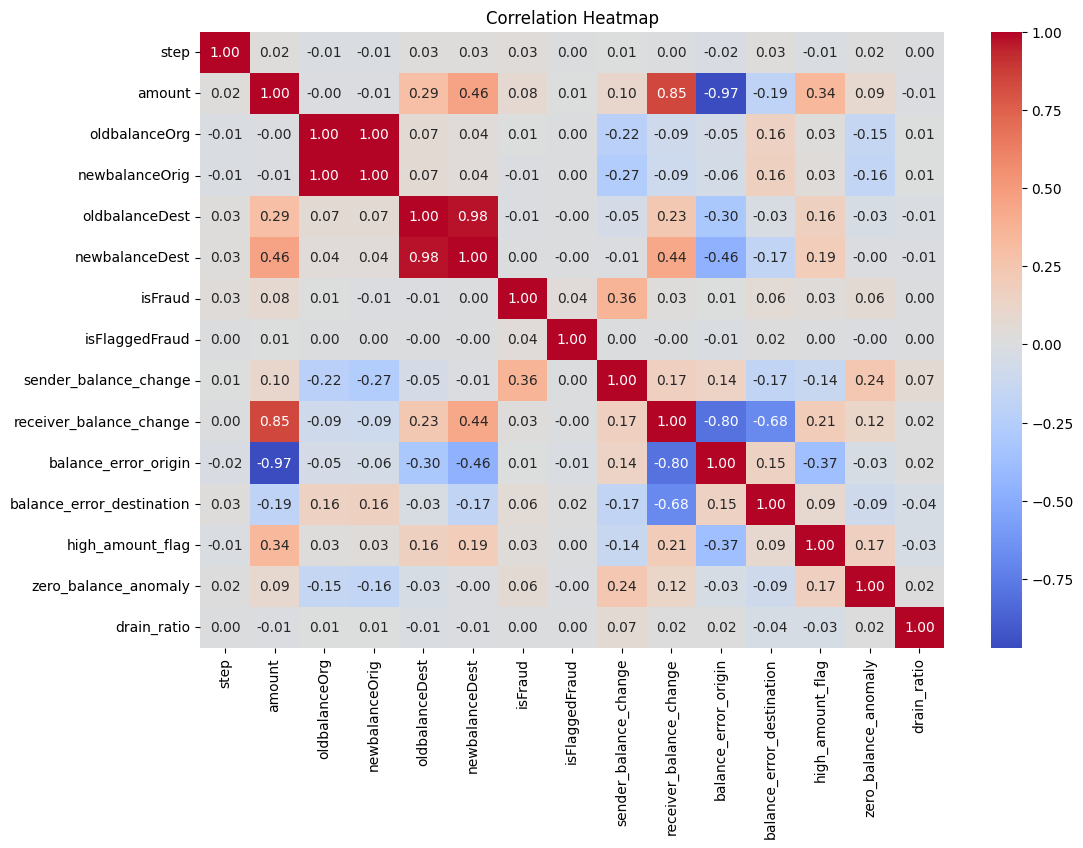

In [13]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 4. Data Cleaning and Feature Engineering
We will remove non-predictive identifiers (`nameOrig`, `nameDest`) and create engineered features that capture the logic of financial fraud, such as balance discrepancies.

In [15]:
# ==========================
# DATA CLEANING
# ==========================

df_clean = df.copy()

# Remove isFlaggedFraud only if present
if 'isFlaggedFraud' in df_clean.columns:
    df_clean.drop(
        columns=['isFlaggedFraud'],
        inplace=True
    )

# ==========================
# FEATURE ENGINEERING
# ==========================

# Sender balance change
df_clean['sender_balance_change'] = (
    df_clean['oldbalanceOrg']
    - df_clean['newbalanceOrig']
)

# Receiver balance change
df_clean['receiver_balance_change'] = (
    df_clean['newbalanceDest']
    - df_clean['oldbalanceDest']
)

# Balance inconsistency at sender
df_clean['balance_error_origin'] = (
    df_clean['oldbalanceOrg']
    - df_clean['amount']
    - df_clean['newbalanceOrig']
)

# Balance inconsistency at receiver
df_clean['balance_error_destination'] = (
    df_clean['oldbalanceDest']
    + df_clean['amount']
    - df_clean['newbalanceDest']
)

# Top 5% transaction amounts
quantile_95 = df_clean['amount'].quantile(0.95)

df_clean['high_amount_flag'] = (
    df_clean['amount'] > quantile_95
).astype(int)

# Sender account completely drained
df_clean['zero_balance_anomaly'] = (
    (df_clean['oldbalanceOrg'] > 0)
    &
    (df_clean['newbalanceOrig'] == 0)
).astype(int)

# Fraud usually occurs in TRANSFER and CASH_OUT
df_clean['suspicious_transfer_flag'] = (
    df_clean['type'].isin(
        ['TRANSFER', 'CASH_OUT']
    )
).astype(int)

# Percentage of balance drained
df_clean['drain_ratio'] = (
    (
        df_clean['oldbalanceOrg']
        -
        df_clean['newbalanceOrig']
    )
    /
    (
        df_clean['oldbalanceOrg']
        + 1
    )
)

# Destination balance growth
df_clean['dest_growth_ratio'] = (
    (
        df_clean['newbalanceDest']
        -
        df_clean['oldbalanceDest']
    )
    /
    (
        df_clean['oldbalanceDest']
        + 1
    )
)

print("Feature Engineering Complete")
print("Shape:", df_clean.shape)

display(df_clean.head())

Feature Engineering Complete
Shape: (6362620, 17)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_change,receiver_balance_change,balance_error_origin,balance_error_destination,high_amount_flag,zero_balance_anomaly,drain_ratio,suspicious_transfer_flag,dest_growth_ratio
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,0.0,9839.64,0,0,0.057834,0,0.000000
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,0.0,1864.28,0,0,0.087731,0,0.000000
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,0.0,181.00,0,1,0.994505,1,0.000000
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0,0.0,21363.00,0,1,0.994505,1,-0.999953
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,0.0,11668.14,0,0,0.280788,0,0.000000


In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["type"] = encoder.fit_transform(
    df["type"]
)

In [17]:
X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

### 6. Preprocessing and Imbalance Handling
We will encode the categorical 'type' column, split the data into training and testing sets using stratification, and calculate the weighting factor for XGBoost to handle the rare fraud class.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pickle

# 6. Preprocessing
# Encode transaction type
le = LabelEncoder()
df_clean['type'] = le.fit_transform(df_clean['type'])

# Define Features and Target
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']

# Stratified Train-Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# 7. Handle Class Imbalance
# Calculate scale_pos_weight: sum(negative instances) / sum(positive instances)
# This tells XGBoost to treat fraud cases with much higher importance.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# 8. Train XGBoost Classifier
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)
print("Model training complete.")

scale_pos_weight = 773.71
Calculated scale_pos_weight: 773.71
[0]	validation_0-auc:0.99933
[100]	validation_0-auc:0.99982
[200]	validation_0-auc:0.99990
[232]	validation_0-auc:0.99990
Model training complete.


k fold

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=kfold,
    n_jobs=-1
)

print("Fold Scores:", scores)
print("Mean ROC-AUC:", scores.mean())

Fold Scores: [0.99976865 0.99975859 0.99888191 0.99995953 0.99977768]
Mean ROC-AUC: 0.9996292738227712


### 9. Model Evaluation
We evaluate the model using a comprehensive set of metrics. Given the class imbalance, Recall and F1-Score are more critical than Accuracy.

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.97      1.00      0.98      1232

    accuracy                           1.00    954393
   macro avg       0.99      1.00      0.99    954393
weighted avg       1.00      1.00      1.00    954393

ROC-AUC Score: 0.9999


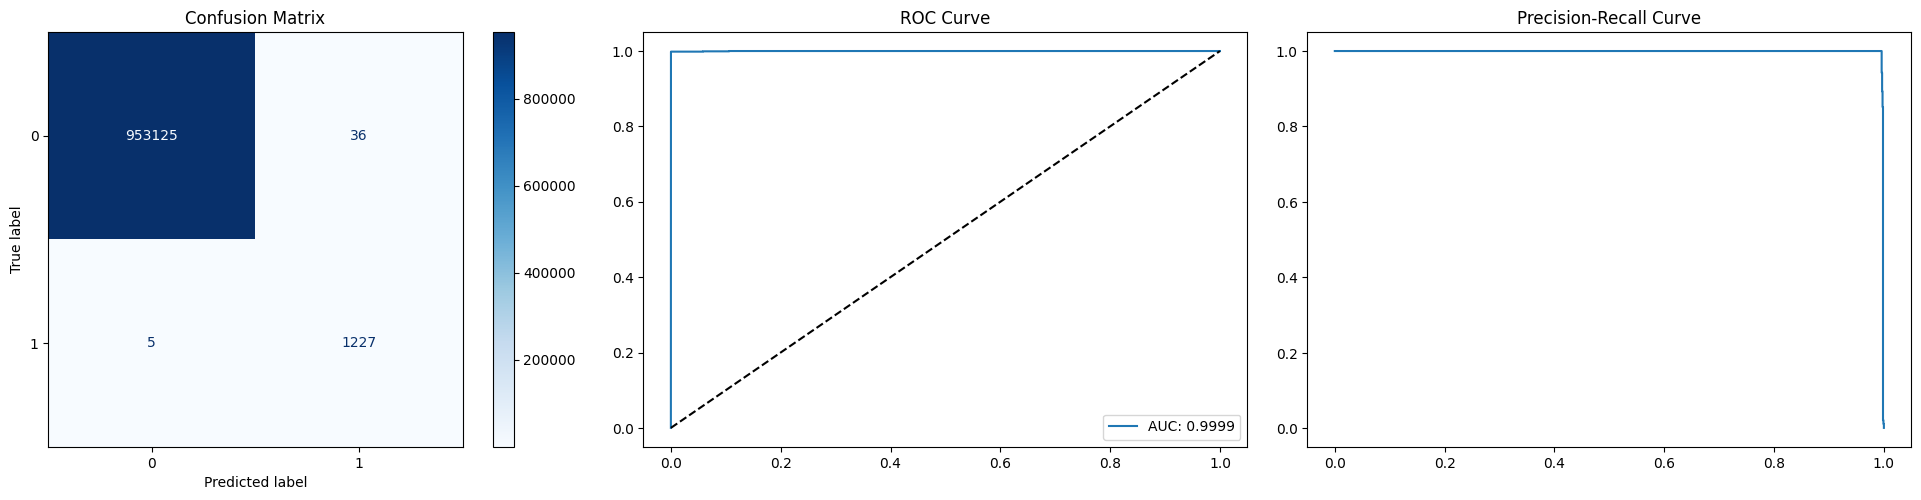

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Visualizations
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f'AUC: {roc_auc_score(y_test, y_proba):.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('ROC Curve')
ax[1].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax[2].plot(recall, precision)
ax[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

### 10. Feature Importance and SHAP Explanations
SHAP (SHapley Additive exPlanations) helps us understand why specific transactions are flagged as fraud.

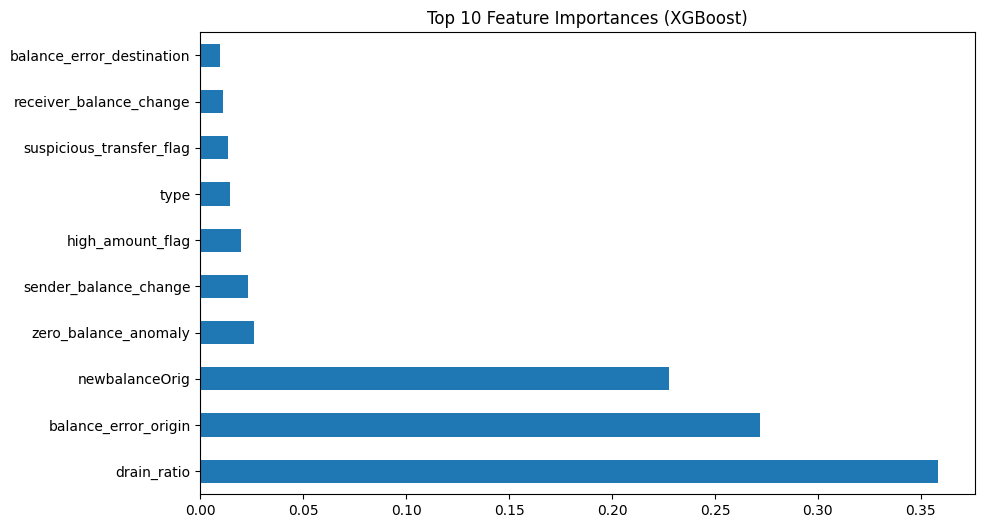

SHAP Summary Plot:


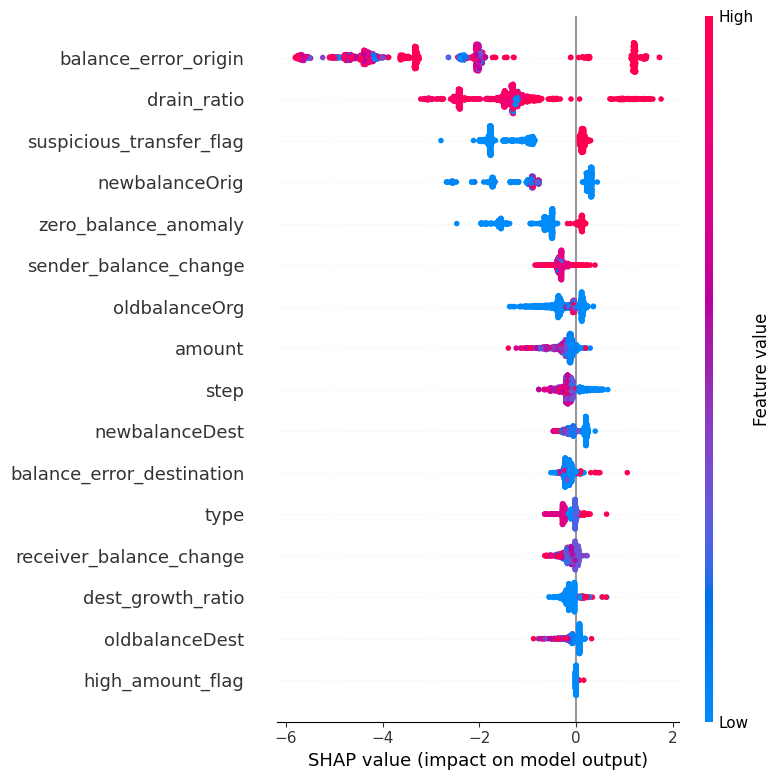

In [21]:
import shap

# Feature Importance Plot
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()

# SHAP Explanations
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:1000])

print("SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test.iloc[:1000])

### 11. Save Artifacts and Prediction Function
We save the model and encoders to files and define the production-ready inference function.

In [30]:
# Save Artifacts
import pickle

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("type_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)


def predict_transaction(transaction_dict):

    input_df = pd.DataFrame([transaction_dict])

    # Encode transaction type
    input_df["type"] = le.transform(
        input_df["type"]
    )

    # Feature Engineering

    input_df["sender_balance_change"] = (
        input_df["oldbalanceOrg"]
        - input_df["newbalanceOrig"]
    )

    input_df["receiver_balance_change"] = (
        input_df["newbalanceDest"]
        - input_df["oldbalanceDest"]
    )

    input_df["balance_error_origin"] = (
        input_df["oldbalanceOrg"]
        - input_df["amount"]
        - input_df["newbalanceOrig"]
    )

    input_df["balance_error_destination"] = (
        input_df["oldbalanceDest"]
        + input_df["amount"]
        - input_df["newbalanceDest"]
    )

    input_df["high_amount_flag"] = (
        input_df["amount"] > quantile_95
    ).astype(int)

    input_df["zero_balance_anomaly"] = (
        (input_df["oldbalanceOrg"] > 0)
        &
        (input_df["newbalanceOrig"] == 0)
    ).astype(int)

    input_df["suspicious_transfer_flag"] = (
        input_df["type"].isin(
            le.transform(
                ["TRANSFER", "CASH_OUT"]
            )
        )
    ).astype(int)

    input_df["drain_ratio"] = (
        (
            input_df["oldbalanceOrg"]
            -
            input_df["newbalanceOrig"]
        )
        /
        (
            input_df["oldbalanceOrg"] + 1
        )
    )

    input_df["dest_growth_ratio"] = (
        (
            input_df["newbalanceDest"]
            -
            input_df["oldbalanceDest"]
        )
        /
        (
            input_df["oldbalanceDest"] + 1
        )
    )

    # Maintain exact training column order
    with open("feature_columns.pkl", "rb") as f:
      feature_columns = pickle.load(f)

    input_df = input_df[feature_columns]

    # Prediction
    prob = model.predict_proba(
        input_df
    )[0][1]

    risk_score = prob * 100

    if risk_score >= 80:
        classification = "FRAUD"
    elif risk_score >= 40:
        classification = "REVIEW"
    else:
        classification = "SAFE"

    return {
        "fraud_probability": round(float(prob), 4),
        "risk_score": round(float(risk_score), 2),
        "classification": classification
    }

In [24]:
with open("quantile_95.pkl", "wb") as f:
    pickle.dump(
        quantile_95,
        f
    )